<a href="https://colab.research.google.com/github/stiltnerag/INFO648/blob/main/Homework_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd


#Part 1: Data Preparation

In [2]:
df=pd.read_csv('/content/churn_synthetic_600_new.csv')

In [5]:
model_df=df

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

numeric_features = ['TenureMonths', 'MonthlyCharge', 'SupportCalls']
categorical_features = ['ContractType', 'PaymentMethod']

preprocess = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder='drop'
)

Because proper data handling is required to manage the missing values, encode categorical variables, prevent bias in feature important metrics, and make sure we address the extreme value scaling for ouputs.

#Part 2: Random Forest Model Construction

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier   # <-- new import
from sklearn.ensemble import HistGradientBoostingClassifier

In [25]:

model = Pipeline([
    ("prep", preprocess),
    ("clf", RandomForestClassifier(
        #max_iter=300,         # number of trees
        n_estimators=300,
        max_depth=20,          # same idea as tree depth
        min_samples_leaf=20,   # minimum leaf size
        random_state=42        # reproducibility
    ))
])

In [24]:
from sklearn.model_selection import train_test_split
X = model_df.drop(columns=['Churn', 'CustomerID'])
y = model_df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

numeric_features = ['TenureMonths', 'MonthlyCharge', 'SupportCalls']


model = Pipeline([
    ("prep", preprocess),
    ("clf",RandomForestClassifier(max_depth=12,min_samples_leaf=18,random_state=42))
])

In [27]:
model.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['TenureMonths',
                                                   'MonthlyCharge',
                                                   'SupportCalls']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ContractType',
                                                   'PaymentMethod'])])),
                ('clf',
                 RandomForestClassifier(max_depth=20, min_samples_leaf=20,
                                        n_estimators=300, random_state=42))])

In [28]:
importances=model.named_steps['clf'].feature_importances_
import pandas as pd

# Get the feature names after preprocessing
transformed_feature_names = model.named_steps['prep'].get_feature_names_out()

feat_imp = pd.Series(importances, index=transformed_feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

feat_imp

,0
num__TenureMonths,0.377743
num__MonthlyCharge,0.335797
num__SupportCalls,0.107960
cat__ContractType_Month-to-Month,0.079337
cat__PaymentMethod_Credit Card,0.032239
cat__PaymentMethod_Electronic Check,0.025657
cat__ContractType_Two-Year,0.021407
cat__ContractType_One-Year,0.010142
cat__PaymentMethod_Bank Transfer,0.009718


Random Forest makes classification decisions by combining the predictions of dozens of individual decision trees. Random Forest reduces variance without increasing bias, due to each tree being intentionally trained on a slightly different data subse. Random Forest typically has a higher level of accuracy and also a lower risk of overfitting.  

#Part 3: Default Threshold Evaluation

In [20]:
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

In [21]:
y_pred

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [30]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_curve, roc_auc_score
proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
print(auc)

0.8247518610421836


In [31]:
from sklearn.metrics import confusion_matrix, classification_report
#Actual first
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[124   0]
 [ 25   1]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       124
           1       1.00      0.04      0.07        26

    accuracy                           0.83       150
   macro avg       0.92      0.52      0.49       150
weighted avg       0.86      0.83      0.76       150



The accuracy is showing 83%, but we notice a class imbalance out of 150 total customers 124 stayed and only 26 churned. Our recall for this model is 4%, so the amount of customers we actually caught who churned was extremely low catching only 1. Precision is 100% but meaningless, this model is extremely safe and eliminating all flase positives.

#Part 4: ROC Curve and AUC Interpretation

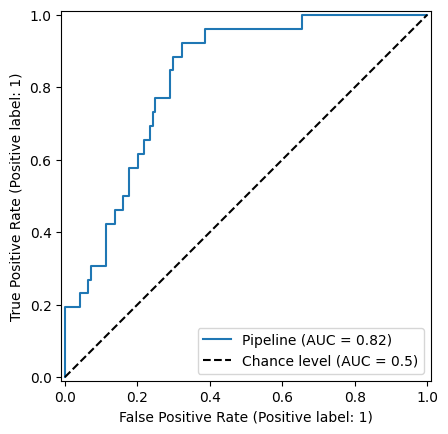

In [32]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model,X_test,y_test,plot_chance_level=True)

1. What does the ROC curve represent in a classification model? ROC shows the true positive and false positive rate relationship across all possible classification thresholds.

2. What does the Area Under the Curve (AUC) measure? Ranking quality, anything over 0.90+ is excellent

3. What does the AUC for this model tell us?  The AUC of 0.82 which is considered decent or useable is telling us that there is a 82% chance our model will assign a higher probability of churn to an actual non-churner.

4. What would an AUC value close to 1.00 imply? A near perfect classifier

5. Why is ROC analysis useful when classification thresholds can change? Because it visualizes the performance of the random forest model across every possible probability threshold at once.

#Part 5: Feature Importance Using an AI Assistant

          RANKED FEATURE IMPORTANCES              
                          Feature  Importance
0                    TenureMonths    0.377743
1                   MonthlyCharge    0.335797
2                    SupportCalls    0.107960
3     ContractType_Month-to-Month    0.079337
4       PaymentMethod_Credit Card    0.032239
5  PaymentMethod_Electronic Check    0.025657
6           ContractType_Two-Year    0.021407
7           ContractType_One-Year    0.010142
8     PaymentMethod_Bank Transfer    0.009718


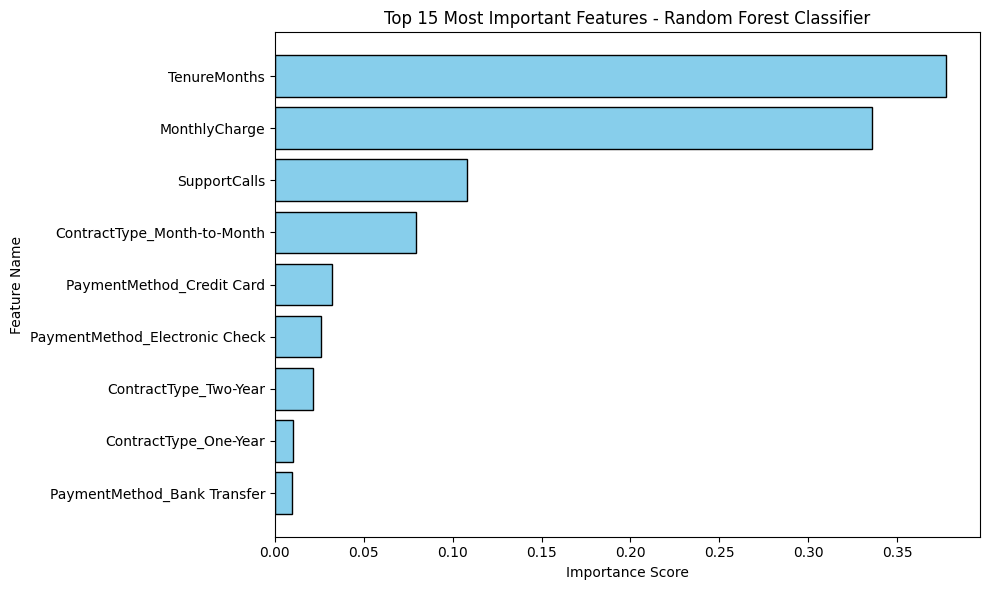

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Step into your pipeline to extract the trained Random Forest model
# Note: Adjust 'classifier' if your pipeline step name is different (e.g., 'model' or 'rf')
rf_model = model.named_steps['clf']

# 2. Extract the feature names from the preprocessor step
# Note: Adjust 'preprocessor' to match your pipeline's preprocessing step name
feature_names = model.named_steps['prep'].get_feature_names_out()

# 3. Extract the feature importances from the Random Forest
importances = rf_model.feature_importances_

# 4. Map names to importances and sort them in descending order
df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 5. Clean up feature names for cleaner display (removes 'cat__' or 'num__' prefixes)
df_importances['Feature'] = df_importances['Feature'].str.replace(r'^(cat|num|remainder)__', '', regex=True)

# 6. Print the ranked features
print("==================================================")
print("          RANKED FEATURE IMPORTANCES              ")
print("==================================================")
print(df_importances.to_string(index=True))
print("==================================================")

# 7. Plot the Feature Importances for your report deliverable
plt.figure(figsize=(10, 6))
plt.barh(df_importances['Feature'][:15][::-1], df_importances['Importance'][:15][::-1], color='skyblue', edgecolor='black')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.title('Top 15 Most Important Features - Random Forest Classifier')
plt.tight_layout()
plt.show()

AI prompt: enerate code that extracts and ranks the Random Forest’s feature_importances_. orrectly map the importances back to the feature names after one-hot encoding (use get_feature_names_out() on the preprocessing step, since the categorical columns 2 are expanded into multiple encoded columns).

Error of not having the pipline defined that I had to correct as well and rerun.

The top features that correlate with business intuition I think are tenure and contract type. Tenure because a customer who has a long history with a company is usually less likely to leave than a new customer. Contract type because those who are locked in for a 1-2 year contract cannot churn without penalty. It is important to note the model could be underestimating the impact of operational binary flags that offer only one single split point.

#Part 6: Reduced-Feature Model

In [39]:

numeric_features_reduced = ['TenureMonths']
categorical_features_reduced = ['ContractType']

preprocess_reduced = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numeric_features_reduced),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_reduced)
    ],
    remainder='drop'
)

In [40]:

model_reduced = Pipeline([
    ("prep", preprocess_reduced),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=20,
        random_state=42
    ))
])


model_reduced.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', MinMaxScaler(),
                                                  ['TenureMonths']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ContractType'])])),
                ('clf',
                 RandomForestClassifier(max_depth=20, min_samples_leaf=20,
                                        n_estimators=300, random_state=42))])

In [43]:
y_pred_reduced = model_reduced.predict(X_test)
proba_reduced = model_reduced.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

auc_reduced = roc_auc_score(y_test, proba_reduced)
print(f"ROC AUC Score (Reduced Model): {auc_reduced:.4f}")

print("\nConfusion Matrix (Reduced Model):")
print(confusion_matrix(y_test, y_pred_reduced))

print("\nClassification Report (Reduced Model):")
print(classification_report(y_test, y_pred_reduced))

ROC AUC Score (Reduced Model): 0.7667

Confusion Matrix (Reduced Model):
[[124   0]
 [ 26   0]]

Classification Report (Reduced Model):
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       124
           1       0.00      0.00      0.00        26

    accuracy                           0.83       150
   macro avg       0.41      0.50      0.45       150
weighted avg       0.68      0.83      0.75       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


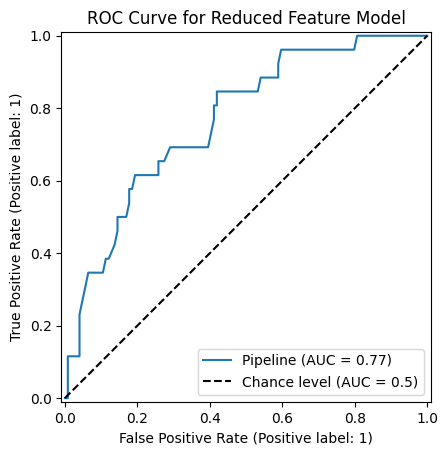

In [44]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model_reduced, X_test, y_test, plot_chance_level=True)
plt.title('ROC Curve for Reduced Feature Model')
plt.show()

•Which metric changed the most? All metrics for class 1 changed, but precision and recall both dropped to 0.00 in the second model making them change the most.

• Did any metric decrease? yes, Class 1 precision, recall and f1 score.

• Would you deploy the full model or the reduced-feature model in practice — and why? The full model, with optimization. I believe the model is in a machine learning trap of predicting the majority class when data is imbalanced.